## Baseline Decision Tree đơn giản
Chỉ sử dụng các cột dữ liệu ban đầu (không qua biến đổi, chỉ bỏ cột có tỉ lệ null > 60% và điền khuyết dữ liệu đơn giản)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

## 1. Nạp và Merge dữ liệu

In [2]:
train_identity    = pd.read_csv("Dataset/train_identity.csv")
train_transaction = pd.read_csv("Dataset/train_transaction.csv")

print(f"train_identity.shape    = {train_identity.shape}")
print(f"train_transaction.shape = {train_transaction.shape}")

train = train_transaction.merge(train_identity, how="left", on="TransactionID")
print(f"Merged train.shape      = {train.shape}")

train_identity.shape    = (144233, 41)
train_transaction.shape = (590540, 394)
Merged train.shape      = (590540, 434)


## 2. Chọn cột

- Bỏ cột có tỉ lệ khuyết > 60%
- Bỏ cột ID (chỉ có tính hình thức)
- Giữ các cột còn lại
- Encode theo danh mục với **label encoding** (yêu cầu của DecisionTree)
- Điền khuyết dữ liệu: **trung vị** với dữ liệu số , **'Missing'** với dữ liệu danh mục

In [3]:
# Drop ID column
train = train.drop(columns=['TransactionID'])

# Drop columns with >60% missing
missing_ratio = train.isnull().mean()
cols_to_drop  = missing_ratio[missing_ratio > 0.6].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >60% missing values")
train = train.drop(columns=cols_to_drop)

print(f"Remaining columns: {train.shape[1]} (including target 'isFraud')")

Dropping 208 columns with >60% missing values
Remaining columns: 225 (including target 'isFraud')


In [4]:
# Separate features and target
X = train.drop(columns=['isFraud'])
y = train['isFraud']

print(f"Feature matrix shape : {X.shape}")
print(f"Class distribution   :\n{y.value_counts()}")
print(f"Fraud rate           : {y.mean():.2%}")

Feature matrix shape : (590540, 224)
Class distribution   :
isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate           : 3.50%


In [5]:
from sklearn.preprocessing import LabelEncoder

# Separate truly numeric vs string columns
# pd.api.types.is_numeric_dtype is more reliable than checking dtype == 'object'
# because some columns are dtype=object but contain numbers mixed with strings
num_cols = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col])]
cat_cols = [col for col in X.columns if not pd.api.types.is_numeric_dtype(X[col])]

print(f"Numeric columns : {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

# Fill missing values
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna('Missing')

# Label-encode categorical columns
print(f"\nEncoding {len(cat_cols)} categorical columns: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Label encoding done.")

Numeric columns : 211
Categorical columns: 13

Encoding 13 categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Label encoding done.


## 3. Train / Val / Test Split  (80 / 10 / 10)

In [6]:
x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
x_val, x_test, y_val, y_test = train_test_split(
    x_val, y_val, test_size=0.5, random_state=42, stratify=y_val
)

print(f"Train : {x_train.shape[0]:>7,} rows")
print(f"Val   : {x_val.shape[0]:>7,} rows")
print(f"Test  : {x_test.shape[0]:>7,} rows")

Train : 472,432 rows
Val   :  59,054 rows
Test  :  59,054 rows


## 4. Train Decision Tree

In [7]:
# Class weight to handle imbalance
model_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

model_dt.fit(x_train, y_train)
print("Training complete.")

Training complete.


## 5. Đánh giá trên tập Validation

In [8]:
y_val_pred      = model_dt.predict(x_val)
y_val_pred_prob = model_dt.predict_proba(x_val)[:, 1]

print("=== Validation Set ===")
print(classification_report(y_val, y_val_pred))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_pred_prob):.4f}")

=== Validation Set ===
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     56987
           1       0.17      0.78      0.27      2067

    accuracy                           0.85     59054
   macro avg       0.58      0.82      0.60     59054
weighted avg       0.96      0.85      0.90     59054

ROC-AUC: 0.8811


## 6. Đánh giá trên tập Test

=== Test Set ===
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     56988
           1       0.16      0.75      0.26      2066

    accuracy                           0.85     59054
   macro avg       0.57      0.80      0.59     59054
weighted avg       0.96      0.85      0.90     59054

ROC-AUC: 0.8688


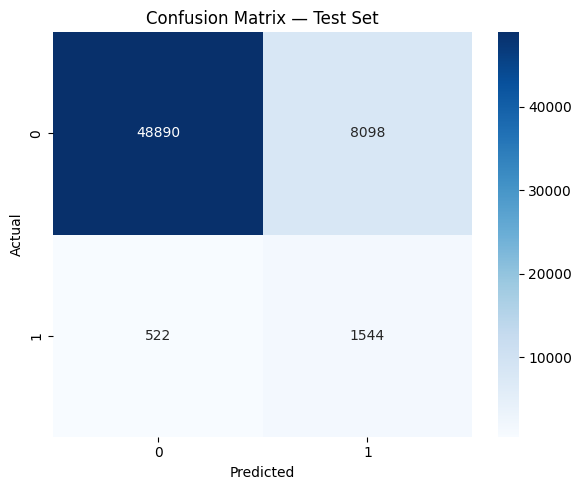

In [9]:
y_test_pred      = model_dt.predict(x_test)
y_test_pred_prob = model_dt.predict_proba(x_test)[:, 1]

print("=== Test Set ===")
print(classification_report(y_test, y_test_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_pred_prob):.4f}")

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 7. Các đặc trưng (cột) quan trọng

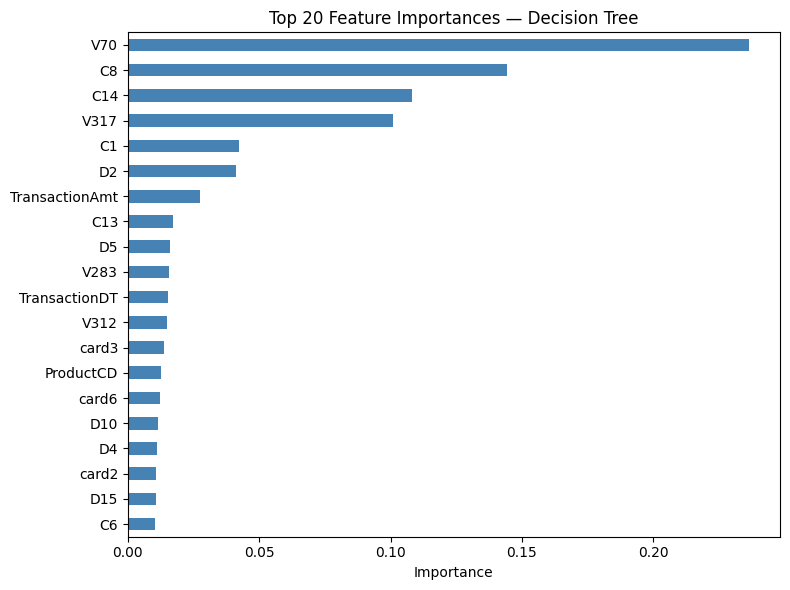

In [10]:
importances = pd.Series(model_dt.feature_importances_, index=x_train.columns)
top20 = importances.nlargest(20)

plt.figure(figsize=(8, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances — Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()